# 1次元正規分布の例（p.46 図4.7(a)）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using CairoMakie # Plots, StatsPlots, gr() から置き換え

  Activating project at `c:\Users\salt_.YO-MOUSE_NO02\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


### 1. 1次元正規分布関数の定義

In [2]:
# 正規分布関数の定義
function N_1dim(x, μ, σ)
    return (1 / √(2π * σ^2)) * exp((-(x - μ)^2 / (2σ^2)))
end

xs = range(-20.0, 20.0, length=100)

-20.0:0.40404040404040403:20.0

### 2. 1次元分布正規関数のプロット

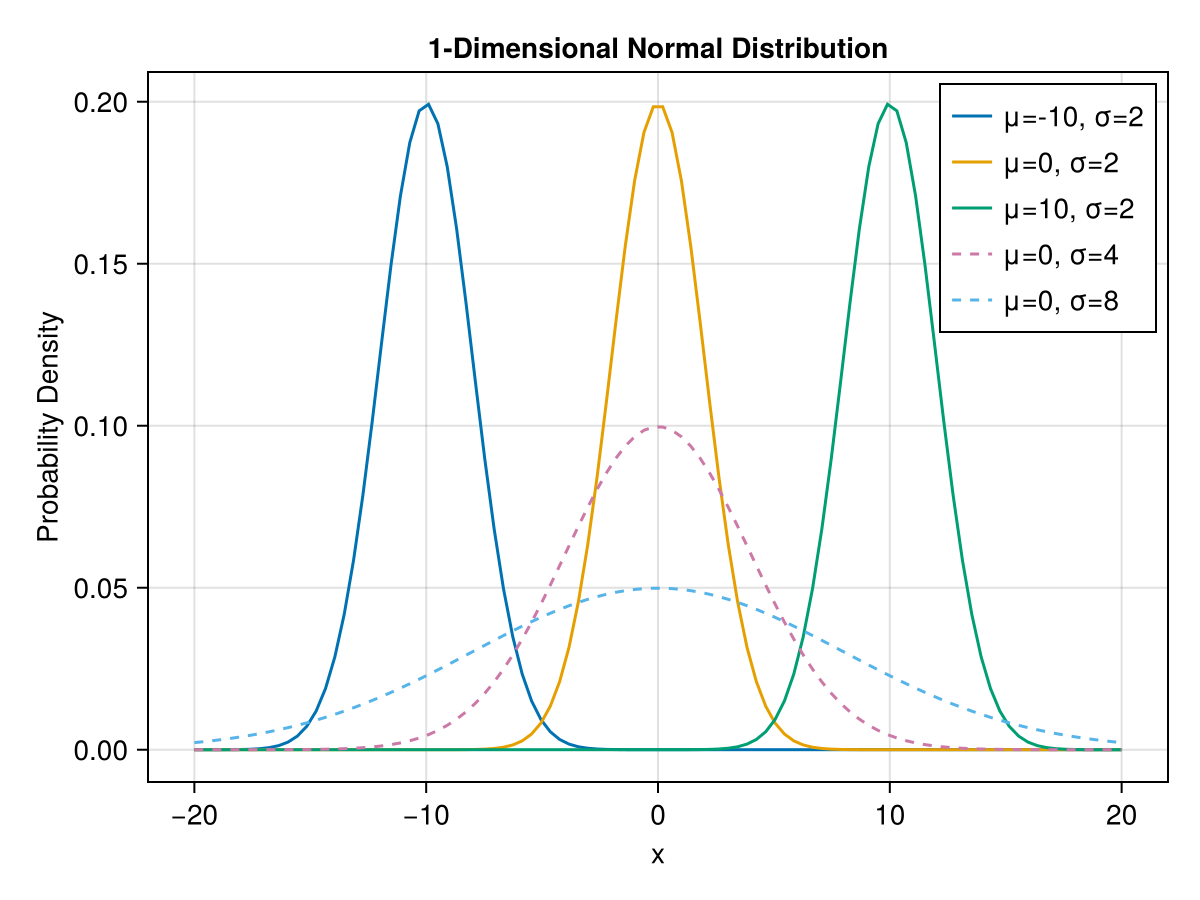

In [3]:
# (1)CairoMakieの設定
# Figure() で外枠、Axis() でグラフの軸（タイトルやラベル）を作成
fig = Figure(size = (600, 450))
ax = Axis(fig[1, 1], 
    title = "1-Dimensional Normal Distribution",
    xlabel = "x", 
    ylabel = "Probability Density"
)

# (2)データのプロット（ax に対して lines! で重ねていく）
# 平均を変化 (σ = 2)
σ_val = 2
for μ_val in [-10, 0, 10]
    # 計算結果を一度ベクトル（Array）として明示的に渡すと安定する
    ys = [N_1dim(x, μ_val, σ_val) for x in xs]
    lines!(ax, xs, ys, label = "μ=$μ_val, σ=$σ_val")
end

# 標準偏差を変化 (μ = 0)
μ_val = 0
for σ_val in [4, 8]
    ys = [N_1dim(x, μ_val, σ_val) for x in xs]
    # linestyle = :dash で点線にする
    lines!(ax, xs, ys, label = "μ=$μ_val, σ=$σ_val", linestyle = :dash)
end

# (3)凡例（Legend）の追加
# 凡例を明示的に位置指定して配置
axislegend(ax, position = :rt) # :rt = right top（右上）

# (4)グラフの保存と表示
save("normal_distribution_1d.png", fig) # 保存
fig # 表示

- `CairoMakie`使用